# Data Analysis Notebook

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    My Overarching Research Question: Do certain Regions of England lag in Further Education Perfomance compared to others?
</h2>

</div>

In [41]:
##  Imports
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

import sys
sys.path.append('../..')
from final_project.scripts.data_analysis_utils import setup_categorical_type

import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    Connecting to the Database stored at ../data/database.db    
</h3>


</div>

In [42]:
engine = create_engine('sqlite:///../data/database.db')

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h1>
    Exploring the Data    
</h1>

Here is a reference for the locations of each region in case you are unfamiliar or, like me, appreciate a visual representation:

<img src="../docs/figures/regions_map.jpg" alt="Description" width="450">


</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    Exploring Retention over time across England
</h2>

</div>

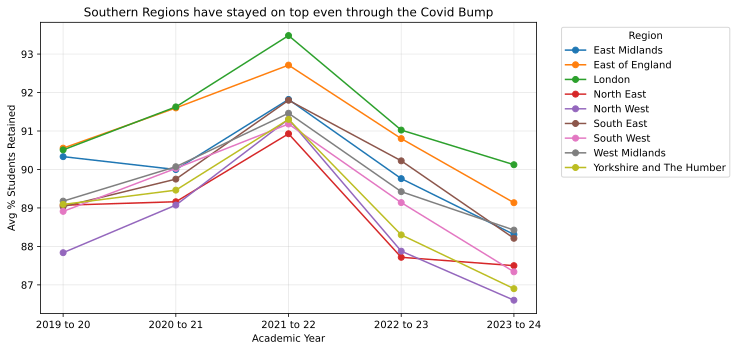

In [59]:
query = """
SELECT time_period, region, AVG(perc_retained) AS avg_perc_retained
FROM retention
GROUP BY region, time_period
ORDER BY time_period, region
"""
pd.read_sql(query, engine)

perc_retained_df = pd.read_sql(query, engine)
pivot_df = perc_retained_df.pivot(index="time_period", columns="region", values="avg_perc_retained")


plt.figure(figsize=(11, 5))
plt.plot(pivot_df, marker="o", label=pivot_df.columns)

plt.xlabel("Academic Year")
plt.ylabel("Avg % Students Retained")
# plt.title("Avg % Students Retained for 16-18 Studies by Region Over Time")
plt.title("Southern Regions have stayed on top even through the Covid Bump")

plt.grid(True, alpha=0.3)
plt.legend(title="Region", bbox_to_anchor=(1.4, 1), loc="upper right")

plt.tight_layout()
plt.savefig("../docs/figures/retention.svg")
plt.show()

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

This graph clearly shows a common trend throughout the UK where the average percentage of students entering any type of 16-18 Studies rose and then fell over the last 5 years. The current academic year 2024-25 who have just finished has not yet had their data published by the DfE, however they would be the vital next datapoint to determine whether the trend line will plateau, recover or get worse. This shape is likely a result of Covid-19, having forced everyone to stay at home and be isolated until mid 2021, the cohort starting that September had more students hoping to re-engage with society and their peers at school, so retention increased. Alternatively, it could be a result of more students receiving higher grades in GCSEs as an outcome of the TAGs (teacher assessed grades - exam alternative) used at the time, allowing more of them to apply for Further Education, subsequently falling when regular exams and grade boundaries were reintroduced. Supported by this figure from a UK Gov Publication, below:
    
<img src="../docs/figures/uk_gov_covid_graph.png" alt="Description" width="500">

However while the overall trend is the same across England, there is a consistent pattern where Southern Regions such as London and East of England (green and orange) are consistently at the top of the pile whereas Northern Regions remain hanging below such as North East and West (red and purple).

This is a key insight and a common complaint of the British people, so I will use this North-South Divide going forward to showcase disparity between regions.
</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    Investigating Regional Performance using Characteristics    
</h2>


</div>

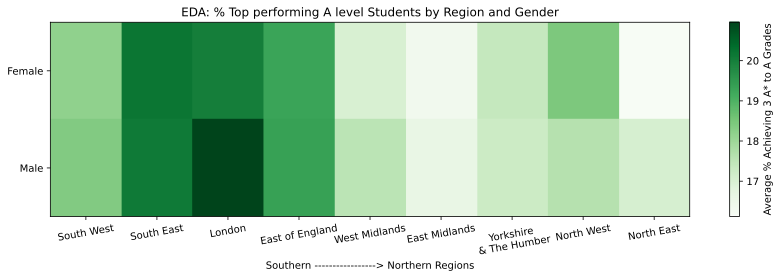

In [55]:
query = """
SELECT
    region,
    characteristic_value AS sex,
    AVG(perc_achieving_3_astar_to_a_grades) AS avg_perc_achieving_top_grades
FROM characteristics
WHERE characteristic_type = 'Sex'
GROUP BY region, characteristic_value
"""
heatmap_df = pd.read_sql(query, engine)

pivot_heatmap = heatmap_df.pivot(index="sex", columns="region", values="avg_perc_achieving_top_grades")
rearranged_df = pivot_heatmap[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                               "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df.rename(columns={"Yorkshire and The Humber": "Yorkshire\n & The Humber"}, inplace=True)

plt.figure(figsize=(12, 4))

plt.imshow(rearranged_df, cmap='Greens', aspect='auto')
plt.colorbar(label="Average % Achieving 3 A* to A Grades")

plt.xticks(ticks=range(len(rearranged_df.columns)), labels=rearranged_df.columns, rotation=10)
plt.yticks(ticks=range(len(rearranged_df.index)), labels=rearranged_df.index)
plt.title("EDA: % Top performing A level Students by Region and Gender")
plt.xlabel("Southern -----------------> Northern Regions")

plt.tight_layout()
plt.show()

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:     
</h3>

From this heatmap, it is clear that while there is not a huge disparity between Genders, there is a clear distinction between how many students are top performers in the South vs. the North.

Perhaps a more robust visualisation would be utilising each characteristic type to discover more focused disparities..

</div>

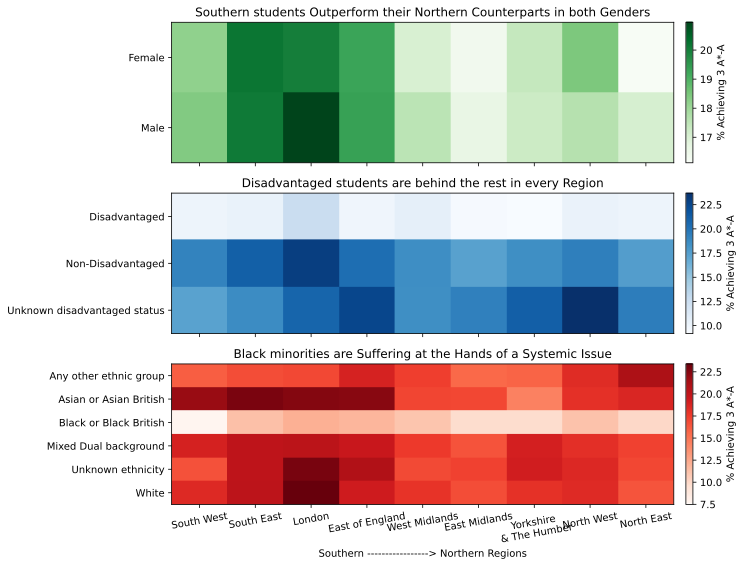

In [60]:
# Characteristic types
characteristic_types = ["Gender", "Disadvantage", "Ethnicity"]

# Consistent region ordering
region_order = [
    "South West", "South East", "London", "East of England", "West Midlands",
    "East Midlands", "Yorkshire and The Humber", "North West", "North East"
]

# Prepare data frames
heatmaps = []
vmin, vmax = None, None  # Will determine global min/max for color scaling

for char_type in characteristic_types:
    query = f"""
        SELECT
            region,
            characteristic_value,
            AVG(perc_achieving_3_astar_to_a_grades) AS avg_top_grades
        FROM characteristics
        WHERE characteristic_type = '{'Sex' if char_type=="Gender" else char_type}'
        GROUP BY region, characteristic_value
    """
    df = pd.read_sql(query, engine)

    # Pivot & rename
    pivot_df = df.pivot(index="characteristic_value", columns="region", values="avg_top_grades")
    pivot_df = pivot_df[[r for r in region_order if r in pivot_df.columns]]  # Ensure column order
    pivot_df = pivot_df.rename_axis(None, axis=0).rename_axis(None, axis=1)
    pivot_df.rename(columns={"Yorkshire and The Humber": "Yorkshire\n & The Humber"}, inplace=True)
    heatmaps.append(pivot_df)

cmaps = ["Greens", "Blues", "Reds"]

# Plotting with individual colorbars
fig, axes = plt.subplots(len(characteristic_types), 1, figsize=(11, 8), sharex=True)
fig.subplots_adjust(hspace=0.6)

for i, (pivot_df, ax) in enumerate(zip(heatmaps, axes)):
    im = ax.imshow(pivot_df.values, aspect='auto', cmap=cmaps[i], vmin=vmin, vmax=vmax)
    if characteristic_types[i] == "Gender":
        title = "Southern students Outperform their Northern Counterparts in both Genders"
    elif characteristic_types[i] == "Disadvantage":
        title = "Disadvantaged students are behind the rest in every Region"
    else:
        title = "Black minorities are Suffering at the Hands of a Systemic Issue"
    ax.set_title(title, fontsize=12)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, rotation=10)

    # Individual colorbar beside each heatmap
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label("% Achieving 3 A*-A")

plt.xlabel("Southern -----------------> Northern Regions")
plt.tight_layout()
plt.savefig("../docs/figures/chars.svg")
plt.show()

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

It is now made very clear by the distinct colours, in what ways the North and South perform differently looking through the lenses of different student characteristics.
In particular:
1. Males and Females perform similarly, so the main disparity showcased is the aforementioned North-South Divide.
2. Disadvantaged students struggle no matter where they are educated. This is a categorical metric defined by DfE that takes into account factors like household income and home address etc.
3. Throughout England, there is a clear drop in top performers of Black ethnic background in every region.

Despite each subplot demonstrating slightly higher percentage of students as top performers (ie. darker colour) on the left side (South), there is a different story about student performance disparities in each. This certainly calls for attention and further analysis should be done to solve these types of, not just regional but, national issues.

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    Exploring common topics of Discussion in British Media and News    
</h2>

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    Looking at students entering Art, Music and Physical Education
</h3>

</div>

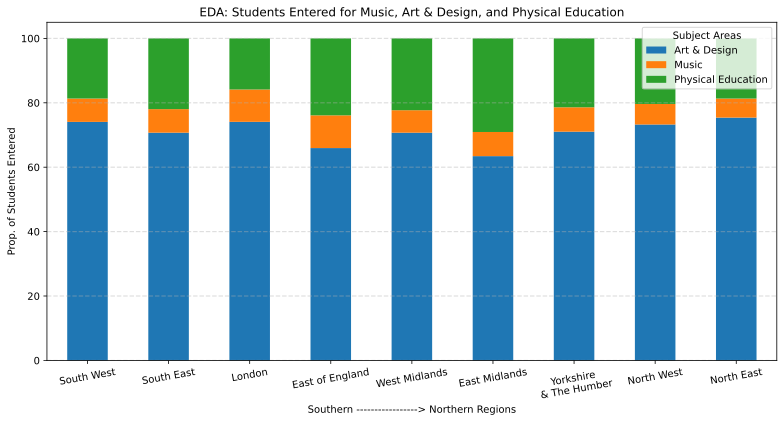

In [61]:
query = """
SELECT
    region,
    subject_area AS subject,
    SUM(number_of_students_entered) AS total_students_entered
FROM results
WHERE subject = 'Music' OR subject = 'Art & Design' OR subject = 'Physical Education'
GROUP BY region, subject
"""
subject_df = pd.read_sql(query, engine)

pivot_subject_df = subject_df.pivot(index="subject", columns="region", values="total_students_entered")
rearranged_df = pivot_subject_df[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

# Convert counts to proportions per region
prop_df = rearranged_df.div(rearranged_df.sum(axis=1), axis=0)

# Optionally multiply by 100 for percentage bars
prop_df *= 100

prop_df.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6)
)

plt.ylabel("Prop. of Students Entered")
plt.xlabel("Southern -----------------> Northern Regions")
plt.title("EDA: Students Entered for Music, Art & Design, and Physical Education")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', linewidth=1.2, alpha=0.4)
plt.legend(title="Subject Areas", loc="upper right")

plt.tight_layout()
plt.show()

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

From this graph it is clear that the Art subject area recieves a lot more students than Music or Physical Education, likely due to the wealth of options and Higher Education (eg. University, Apprenticeships etc.) options is provided compared to the other two.

However there is not a significant difference in the proportions of students who take these particular subjects between regions. The main point made by British News is often that there is significantly less students engaging in these "creative" and "active" subjects compared to the past but since my data is limited to 5 academic years that will not be a meaninful analysis for me to pursue.

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    Looking into Rural vs. Urban student populations
</h3>


</div>

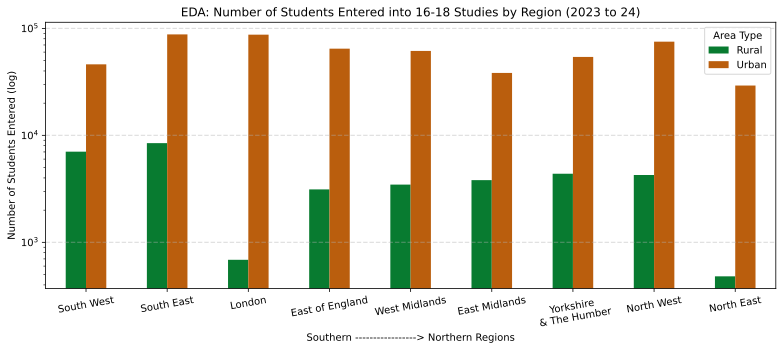

In [63]:
query = """
SELECT
    region,
    CASE
        WHEN rurality LIKE '%Rural%' THEN 'Rural'
        WHEN rurality LIKE '%Urban%' THEN 'Urban'
    END AS rurality_type,
    SUM(number_of_students_completed) AS total_students
FROM rurality
WHERE time_period = '2023 to 24'
GROUP BY region, rurality_type
ORDER BY region, rurality_type
"""
rurality_comp_df = pd.read_sql(query, engine)

pivot_rurality = rurality_comp_df.pivot(index="rurality_type", columns="region", values="total_students")
rearranged_df = pivot_rurality[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

colour_map = {'Rural': "#087B30", 'Urban': "#ba5e0d"}  # blue & orange

rearranged_df.plot(
    kind='bar',
    stacked=False,
    figsize=(11, 5),
    color=[colour_map[col] for col in rearranged_df.columns]
)

plt.yscale("log")
plt.ylabel("Number of Students Entered (log)")
plt.xlabel("Southern -----------------> Northern Regions")
plt.title("EDA: Number of Students Entered into 16-18 Studies by Region (2023 to 24)")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', linewidth=1.2, alpha=0.4)
plt.legend(title="Area Type", loc="upper right")

plt.tight_layout()
plt.show()


<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

Here again, delving further into Rural vs. Urban differences will not be meaningful as it would be a very unbalanced analysis since it is clear there is no region of the UK with a significant proportion of Rural students compared to others or even any region with somewhat equalivalent numbers of Rural and Urban based students.

This is a limitation of my database and analysis choices as I am sticking to a regional scale whereas this analysis is likely to be more relevant on a smaller (eg. city/ town) scale, therefore I will not be using this distinction in further analysis.

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    Looking at Males vs. Females in STEM     
</h3>


</div>

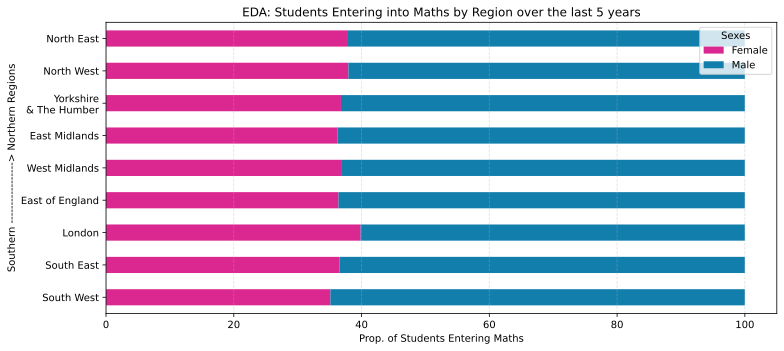

In [64]:
query = """
SELECT
    region,
    sex,
    SUM(number_of_students_entered) AS avg_entered
FROM stem
WHERE sex IN ('Male', 'Female')
    AND subject_combination LIKE '%math%'
GROUP BY region, sex
"""
stem_df = pd.read_sql(query, engine)

pivot_stem_df = stem_df.pivot(index="sex", columns="region", values="avg_entered")
rearranged_df = pivot_stem_df[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

# Convert counts to proportions per region
prop_df = rearranged_df.div(rearranged_df.sum(axis=1), axis=0)

# Optionally multiply by 100 for percentage bars
prop_df *= 100

colour_map = {'Male': "#127EAC", 'Female': "#da2890"}  # blue & orange

prop_df.plot(
    kind='barh',
    stacked=True,
    figsize=(11, 5),
    color=[colour_map[col] for col in prop_df.columns]
)

plt.xlabel("Prop. of Students Entering Maths")
plt.ylabel("Southern -----------------> Northern Regions")
plt.title("EDA: Students Entering into Maths by Region over the last 5 years")
plt.xticks(rotation=10)

plt.grid(axis="x", linestyle='--', alpha=0.4)
plt.legend(title="Sexes", loc="upper right")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

There is evidently a pattern throughout England where Maths based subjects are taken by a greater number of males than females, consistently with a ratio ~ 3:2 respectively.

While there is not a significant change in this between regions, this is a reasonably balanced way to separate and compare the engagement of students in STEM so I will use this as a factor when investigating uptake of STEM subjects..

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    Investigating the Uptake of STEM Subjects    
</h2>


</div>

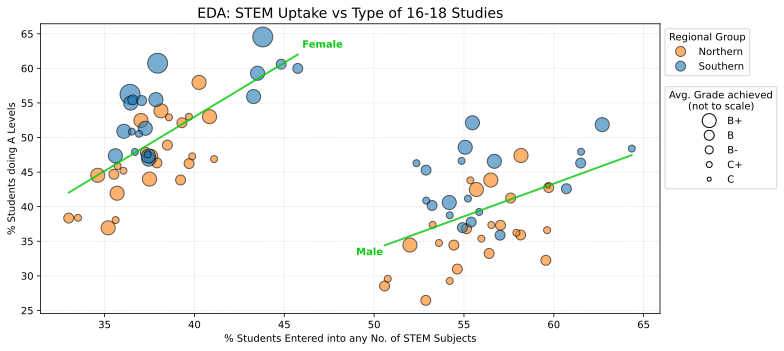

In [65]:
query = """
SELECT
    s.region,
    s.time_period,
    s.sex,
    SUM(s.perc_entered_comb) AS perc_students_entered_stem,
    c.perc_completing_a_levels,
    c.average_a_level_grade
FROM stem AS s
JOIN characteristics AS c
    ON s.region = c.region
    AND s.time_period = c.time_period
    AND s.sex = c.characteristic_value
WHERE c.characteristic_type = 'Sex'
GROUP BY s.region, s.time_period, s.sex
"""
merged_df = pd.read_sql(query, engine)

convert_grades = {'B+': 400, 'B': 200, 'B-': 100, 'C+': 50, 'C': 25}
merged_df['average_a_level_grade_value'] = merged_df["average_a_level_grade"].map(convert_grades)

convert_regions = {
    "South West": "Southern",
    "South East": "Southern",
    "London": "Southern",
    "East of England": "Southern",
    "West Midlands": "Northern",
    "East Midlands": "Northern",
    "Yorkshire and The Humber": "Northern",
    "North West": "Northern",
    "North East": "Northern"
}
merged_df['regional_group'] = merged_df['region'].map(convert_regions)
colour_map = {'Southern': '#1f77b4', 'Northern': '#ff7f0e'}  # blue & orange

fig, ax = plt.subplots(figsize=(11, 5))
for regional_group in merged_df['regional_group'].unique():
    data = merged_df[merged_df['regional_group'] == regional_group]
    ax.scatter(
        data['perc_students_entered_stem'],
        data['perc_completing_a_levels'],
        s=data['average_a_level_grade_value'],
        alpha=0.6,
        c=colour_map[regional_group],
        label=regional_group,
        edgecolor='k'
    )

for group in ["Male", "Female"]:
    x = merged_df[merged_df["sex"]==group]['perc_students_entered_stem']
    y = merged_df[merged_df["sex"]==group]['perc_completing_a_levels']
    coeffs = np.polyfit(x, y, deg=1)
    trend_y = np.polyval(coeffs, x)

    ax.plot(x, trend_y, color="#09c70f", linestyle='-', linewidth=2, alpha=0.8)
    
    if group=="Female":
        text_x, text_y = 46, 63
    else:
        text_x, text_y = 49, 33
    ax.text(text_x, text_y, group, color="#09c70f", fontweight="bold")

# Labels and title
ax.set_xlabel("% Students Entered into any No. of STEM Subjects")
ax.set_ylabel("% Students doing A Levels")
ax.set_title("EDA: STEM Uptake vs Type of 16-18 Studies", fontsize=14)

handles1 = [
    plt.Line2D([], [], color='w', marker='o', markerfacecolor=colour_map[regional_group], alpha=0.6, 
                  markeredgecolor='k', markersize=10, label=regional_group) 
                  for regional_group in merged_df['regional_group'].unique()
]
legend1 = plt.legend(handles=handles1, title="Regional Group", loc="upper left", bbox_to_anchor=(1, 1))
plt.gca().add_artist(legend1)


legend_sizes = {'B+': 14, 'B': 10, 'B-': 8, 'C+': 6, 'C': 4}
handles2 = [
    plt.Line2D([], [], color='w', marker='o', markerfacecolor="white",
                  markeredgecolor='k', markersize=legend_sizes[grade], label=grade) 
                  for grade in convert_grades.keys()
]
plt.legend(handles=handles2, title="Avg. Grade achieved\n      (not to scale)", loc="upper left",
           bbox_to_anchor=(1, 0.8))


ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

The two clusters are formed naturally by the distinction between males and females, where males tend to engage with STEM subjects at a higher proportion than females.On the other hand, it seems that although a lower proportion of females take STEM subjects, they actually achieve higher grades on average compared to males.

However the main insight is the repeated pattern in both clusters where Northern Regions (orange) tend to make up the bottom half and Southern Regions (blue) tend to make up the top half. Therefore from the trend-lines (green) we can see that:
1. Southern Regions tend to have slightly higher proportion of their students taking A levels as opposed to other 16-18 options, this is an indicator that these Regions are encouraging their students to aim for Higher Education (eg. University, Apprenticeships etc.) as A levels are the most reliable method of entry.
2. Also Southern Regions tend to have greater proportion of students engaging with STEM subjects regardless of gender, whether this is due to the more expansive options found in A levels compared to other types of 16-18 Studies or because the South is better at convincing their students is not clear.

As an alternative visualisation, it may be more informative to look at how STEM uptake relates with students completing their A levels in particular..
</div>

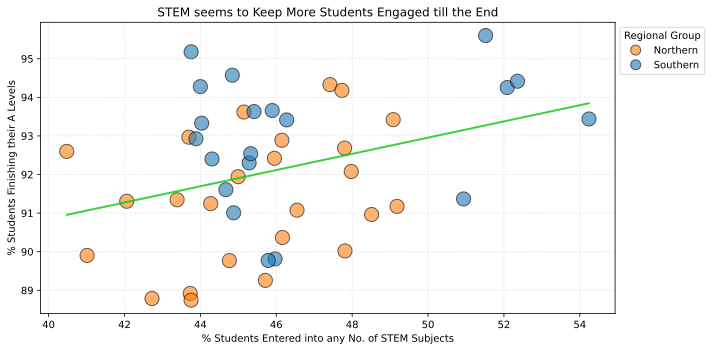

In [68]:
query = """
SELECT
    s.region,
    s.time_period,
    SUM(s.perc_entered_comb) AS perc_students_entered_stem,
    r.perc_retained_and_assessed
FROM stem AS s
JOIN retention AS r
    ON s.region = r.region
    AND s.time_period = r.time_period
WHERE s.sex = "All"
    AND r.cohort = "A level"
GROUP BY s.region, s.time_period
"""
merged_df = pd.read_sql(query, engine)

convert_regions = {
    "South West": "Southern",
    "South East": "Southern",
    "London": "Southern",
    "East of England": "Southern",
    "West Midlands": "Northern",
    "East Midlands": "Northern",
    "Yorkshire and The Humber": "Northern",
    "North West": "Northern",
    "North East": "Northern"
}
merged_df['regional_group'] = merged_df['region'].map(convert_regions)

colour_map = {'Southern': '#1f77b4', 'Northern': '#ff7f0e'}  # blue & orange

fig, ax = plt.subplots(figsize=(10, 5))
for regional_group in merged_df['regional_group'].unique():
    data = merged_df[merged_df['regional_group'] == regional_group]
    ax.scatter(
        data['perc_students_entered_stem'],
        data['perc_retained_and_assessed'],
        s=200,
        alpha=0.6,
        c=colour_map[regional_group],
        label=regional_group,
        edgecolor='k'
    )
x = merged_df['perc_students_entered_stem']
y = merged_df['perc_retained_and_assessed']
coeffs = np.polyfit(x, y, deg=1)
trend_y = np.polyval(coeffs, x)

ax.plot(x, trend_y, color="#09c70f", linestyle='-', linewidth=2, alpha=0.8)

# Labels and title
ax.set_xlabel("% Students Entered into any No. of STEM Subjects")
ax.set_ylabel("% Students Finishing their A Levels")
#ax.set_title("STEM Uptake vs Completion of A levels", fontsize=14)
ax.set_title("STEM seems to Keep More Students Engaged till the End")

handles = [
    plt.Line2D([], [], color='w', marker='o', markerfacecolor=colour_map[regional_group], alpha=0.6, 
                  markeredgecolor='k', markersize=10, label=regional_group) 
                  for regional_group in merged_df['regional_group'].unique()
]
plt.legend(handles=handles, title="Regional Group", loc="upper left", bbox_to_anchor=(1, 1))

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/figures/stem.svg")
plt.show()


<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

Now looking specifically at those studying A levels and likely aiming for Higher Education (eg. University, Apprenticeships etc.), we can see an almost identical trend to before where the cluster (now made up of all genders in one) contains Northern Regions (orange) in the bottom half and Southern Regions (blue) in the top half with a similarly positive sloped trend-line (green).

In this case we can infer that when more students in a cohort are taking A level STEM subjects then a greater proportion of the students return for a second year of study and earn their A level qualifications. Perhaps they are more motivated to complete their studies and pursue Higher Education, alternatively they might be more inclined to do so since they are more academic in nature, having taken STEM subjects in the first place. More controversially, it may be down to the environment (in which more STEM subjects are being taken) that makes them feel more capable and therefore return for their second year of studies and complete the exams for their A levels.

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    Extra Exploration: Regional Disparities in Performance across all Subjects  
</h2>


</div>

C:\Users\kiaka\AppData\Local\Temp\ipykernel_56396\213696940.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
C:\Users\kiaka\AppData\Local\Temp\ipykernel_56396\213696940.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=10)


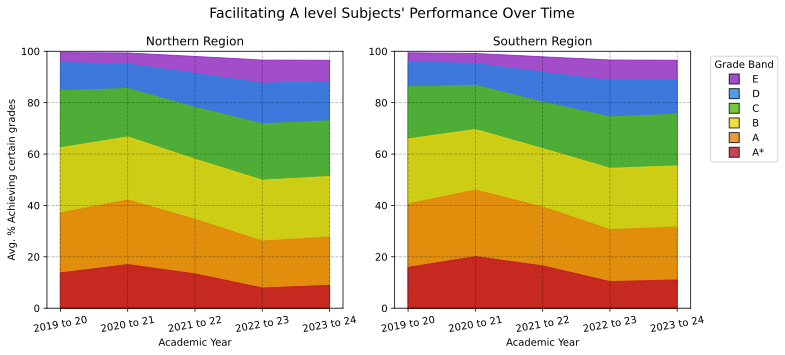

In [51]:
query = """
SELECT 
    region,
    time_period,
    AVG(perc_astar_grade_achieved) AS avg_perc_astar,
    AVG(perc_astar_to_a_grade_achieved) AS avg_perc_astar_to_a,
    AVG(perc_astar_to_b_grade_achieved) AS avg_perc_astar_to_b,
    AVG(perc_astar_to_c_grade_achieved) AS avg_perc_astar_to_c,
    AVG(perc_astar_to_d_grade_achieved) AS avg_perc_astar_to_d,
    AVG(perc_astar_to_e_grade_achieved) AS avg_perc_astar_to_e
FROM results
WHERE qualification = 'A level'
    AND subject_area = 'All facilitating subjects'
GROUP BY region, time_period
"""
avg_results_df = pd.read_sql(query, engine)

avg_results_df['regional_group'] = avg_results_df['region'].map(convert_regions)

grade_levels = ['avg_perc_astar', 'avg_perc_astar_to_a', 'avg_perc_astar_to_b', 'avg_perc_astar_to_c',
                'avg_perc_astar_to_d', 'avg_perc_astar_to_e']
grouped_df = avg_results_df.groupby(['regional_group', "time_period"])[grade_levels].mean().reset_index()


grade_cols = ['avg_perc_astar_to_e', 'avg_perc_astar_to_d', 'avg_perc_astar_to_c', 'avg_perc_astar_to_b',
              'avg_perc_astar_to_a', 'avg_perc_astar']
colours = ["#8b21bc","#2583e2","#52ba0d","#eed40e","#E57F0B", "#bf1126"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for i, region in enumerate(grouped_df['regional_group'].unique()):
    ax = axes[i]
    subset = grouped_df[grouped_df['regional_group'] == region]

    for j, col in enumerate(grade_cols):
        ax.fill_between(
            subset['time_period'],
            subset[col],
            color=colours[j],
            alpha=0.8,
            label=col.replace('avg_perc_', '').upper()
        )

    ax.set_title(f"{region} Region")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Academic Year")
    ax.grid(True, linestyle='--', color="black", alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=10)

axes[0].set_ylabel("Avg. % Achieving certain grades")

handles = [
    plt.Line2D([], [], color='w', marker='s', markerfacecolor=colours[i], alpha=0.8, 
                  markeredgecolor='k', markersize=10, label=grade) 
                  for i, grade in enumerate(['E', 'D', 'C', 'B', 'A', 'A*'])
]
plt.legend(handles=handles, title="Grade Band", loc="upper left", bbox_to_anchor=(1.05, 1))

plt.suptitle("Facilitating A level Subjects' Performance Over Time", fontsize=14)
plt.tight_layout()
plt.show()


<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h3>
    What this means:    
</h3>

In this case I limit the scope to facilitating subjects under the A level qualification which are defined by the DfE as subjects which allow students to be able to apply to a range of University degrees or other Higher Education pathways like Apprenticeships, and according to DfE, these subjects indicate "academic excellence and readiness".

Under these constraints, we can see a very similar distribution between the North and South but there is a consistent pattern of Southern Regions achieving a slightly higher proportion of top grades (A*-B) and less of the lower grades (C-E). While the difference is not necessarily that strong, it does reinforce the same pattern I have shown throughout this analysis that the South really does perform slightly better that the North, shown in a variety of ways.

</div>

<div style="padding: 0px 0px 0px 20px; border-left: 8px solid #ED9255; border-radius: 8px">
<h2>
    Review    
</h2>

1. Answering the Reasearch Question:

I think, from the data and analysis I have been able to do, that I have been able to showcase the differences between Regions of England and in particular identify, while it is not by a huge margin, that it is the Northern Regions that lag in Further Education Performance compared to the Southern Regions.

2. Limitations:

Many of the features and disparities I uncovered could be delved into further by looking on a smaller scale such as individual cities, or with additional data such as types of institutions etc. However, looking from a Regional perspective I was still able to uncover the well known North-South Divide and I showed the differences across this divide in a few different ways including through Retention, Regional Performance and the patterns surrounding different characteristic indicators as well as a deeper dive into the patterns around STEM subjects in particular.

3. Extending in the Future:

To extend this analysis in the future I could collect a wider range of data as mentioned beforehand in order to provide more indepth comparisons. Alternatively, I could extend it in a different way by incorporating new data for example from UCAS on University Subjects, Grades and Entry Pathways or from HESA (Higher Education Statistics Agency) on Graduate activities and work including Salary and Tax Bands etc. This type of analysis would allow me to chart educational tradjectories from beginning to end, allowing for a more insightful analysis, this would be the best way to step up this project in the future.

</div>